In [1]:
from diffusers import DiffusionPipeline, DDPMPipeline
import matplotlib.pyplot as plt
import torch
from PIL import Image
import os
import numpy as np
import helper_data
import helper_model

/Users/l0k00au/Projects/Leoric/AI/leoric.kb.ai.huggingface/.venv/lib/python3.14/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


In [2]:
device = helper_model.get_device()

pipe = DiffusionPipeline.from_pretrained(
        pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16,
        use_safetensors=True
    ).to(device)

Using device: MPS (Apple Silicon GPU)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You are using a model of type clip_text_model to instantiate a model of type clip. This is not supported for all configurations of models and can yield errors.
You are using a model of type clip_text_model to instantiate a model of type clip. This is not supported for all configurations of models and can yield errors.


In [3]:
generator = torch.Generator(device=device)

prompt = "A puppy riding a skateboard in Times Square."

# Using 40 steps provides a good balance between quality and speed
# (Typical range: 20-50 for fast generation, 50-150 for high quality)
images = pipe(
    prompt,                 # What you want the model to create
    num_inference_steps=2, # How many denoising steps to use (more steps = more detail/compute)
    generator=generator     # Ensures reproducible noise/randomness
).images


  0%|          | 0/2 [00:00<?, ?it/s]

/Users/l0k00au/Projects/Leoric/AI/leoric.kb.ai.huggingface/.venv/lib/python3.14/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


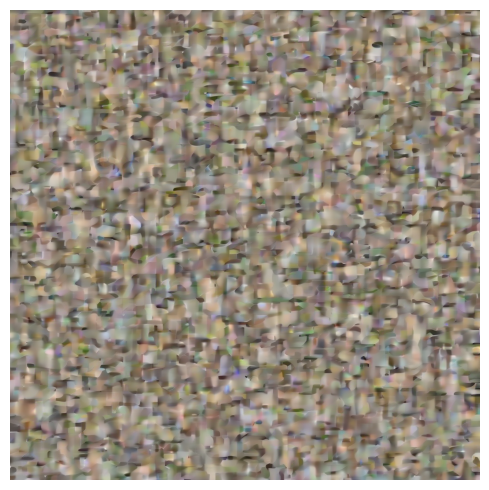

In [4]:
helper_data.show_images(images)